# 05 — Evaluación (Evaluation)

**Fase CRISP-DM:** Evaluación.

**Lee de:** `models/logistic_regression.joblib`, `data/processed/test.csv`.

**Produce:** `reports/figures/logistic_regression_confusion_matrix.png`, `reports/figures/logistic_regression_roc_curve.png`, `reports/tables/logistic_regression_metrics.json`.

La lógica de cálculo de métricas vive en `src/models/evaluate_model.py` y se orquesta desde `src/pipeline.py::evaluate`. Este notebook llama a esa función, sobre el conjunto de **test** (nunca visto durante el entrenamiento ni la validación cruzada de 04).

Métricas sobre el conjunto de TEST:
  accuracy: 0.687
  precision: 0.940
  recall: 0.680
  f1: 0.789
  roc_auc: 0.760


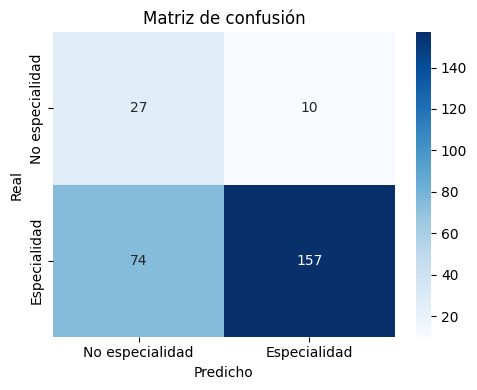

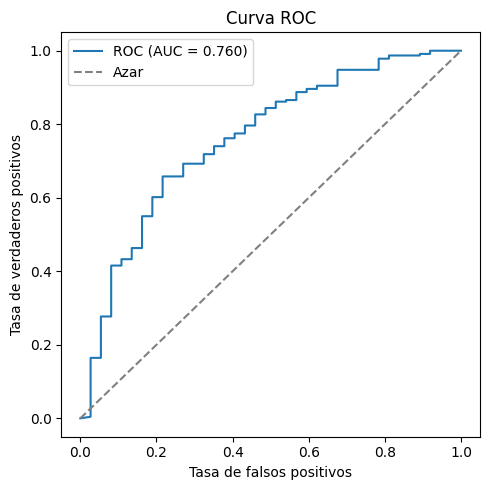

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, "..")  # para poder importar src/ desde notebooks/

from src.config import load_config
from src import pipeline

config = load_config()
eval_result = pipeline.evaluate(config, model_name="logistic_regression")

print("Métricas sobre el conjunto de TEST:")
for metric, value in eval_result["metrics"].items():
    print(f"  {metric}: {value:.3f}")

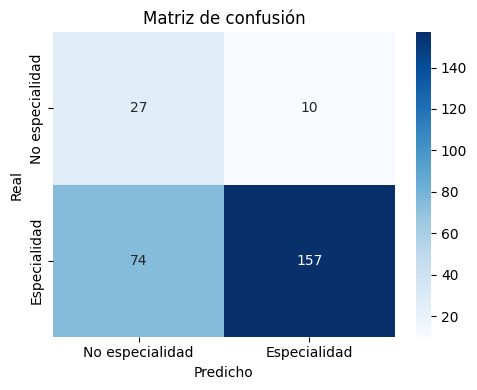

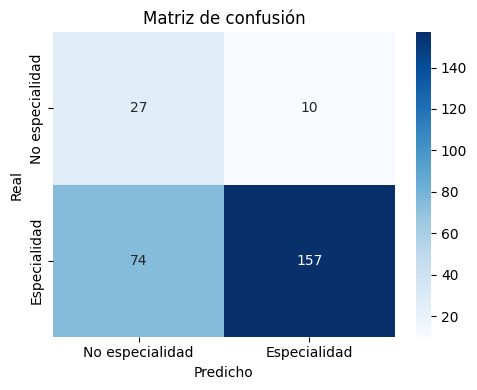

In [2]:
from src.visualization.plots import plot_confusion_matrix, plot_roc_curve

plot_confusion_matrix(eval_result["confusion_matrix"], config, "logistic_regression_confusion_matrix.png")

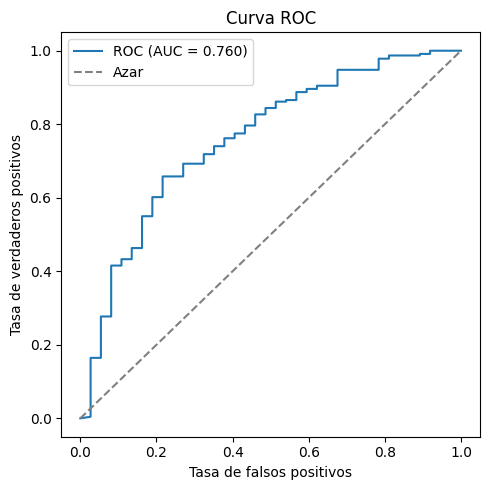

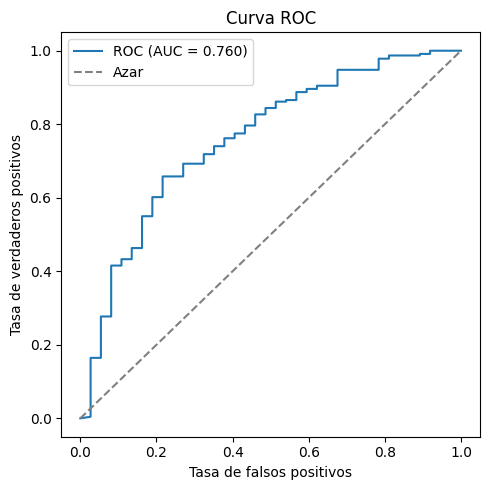

In [3]:
plot_roc_curve(eval_result["fpr"], eval_result["tpr"], eval_result["metrics"]["roc_auc"], config, "logistic_regression_roc_curve.png")

## Análisis de errores

Lotes reales de "café de especialidad" que el modelo NO detectó (falsos negativos) — el error que más le cuesta a este modelo, según la matriz de confusión.

In [4]:
errores = eval_result["X_test"].copy()
errores["real"] = eval_result["y_test"].values
errores["predicho"] = eval_result["y_pred"]
errores["proba_especialidad"] = eval_result["y_proba"]

falsos_negativos = errores[(errores["real"] == 1) & (errores["predicho"] == 0)]
print(f"Falsos negativos: {len(falsos_negativos)} de {len(errores)} lotes de test")
falsos_negativos[["species", "Country.of.Origin", "Variety", "Processing.Method", "proba_especialidad"]].head(10)

Falsos negativos: 74 de 268 lotes de test


,species,Country.of.Origin,Variety,Processing.Method,proba_especialidad
4,arabica,Guatemala,Bourbon,Washed / Wet,0.360014
6,arabica,Mexico,Bourbon,Washed / Wet,0.315055
10,arabica,Nicaragua,NaN,NaN,0.229642
13,arabica,Guatemala,NaN,NaN,0.412545
19,arabica,Thailand,NaN,Washed / Wet,0.377948
23,arabica,Guatemala,Bourbon,Washed / Wet,0.364239
24,arabica,Mexico,Caturra,Washed / Wet,0.209209
28,arabica,Mexico,Typica,Washed / Wet,0.228303
31,arabica,United States (Hawaii),NaN,NaN,0.402877
32,arabica,Mexico,Typica,Washed / Wet,0.370714


## Contraste con los criterios de éxito

`01_comprension_del_negocio.ipynb` deja los criterios de éxito (métrica objetivo y umbral mínimo aceptable) marcados como `TODO (autor)` — son una decisión del equipo, no algo que se pueda inferir del código. Una vez el equipo los complete, esta sección debe agregar la comparación explícita contra las métricas de test obtenidas abajo.